# Synthetic deformation


1. Synthetic recreation of ground truth
    1. Source patterns at max opening
    2. Per station comparison of components
2. New proposed deformation - same plots as above

In [1]:
# first import libraries, data and helper functions 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import scipy.io
from scipy.signal import detrend

import sys
import os
import time
import xarray as xr
import pickle
import pandas as pd
import cartopy.crs as ccrs
import cartopy as crt
sys.path.append(os.path.abspath('okada_python_scripts/..'))

from okada_python_scripts_streamlined.DC3D import DC3D

The next block loads in the forward strain results, calculated within the notebook fwd_strain_drainage. These results are built around flat-bed inversion results from Larochelle et al. (in prep).

In [2]:
# load Larochelle inversion results
with open("a11_drainage_timeseries.pkl", "rb") as file:
    data_dict=pickle.load(file)
    
dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]

# Extract time and z
time = data_dict.pop("time")
z = data_dict.pop("z").flatten()
x = data_dict.pop("x")
y = data_dict.pop("y")

# Process all data variables
data_vars = {
    key: (("time", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
    for key, value in data_dict.items()
}

# Create xarray.Dataset
ds_a11 = xr.Dataset(
    data_vars,
    coords={
        "time": time,
        "z": z,
        "disl": dislocations,
    },
)

with open("a13_drainage_timeseries.pkl", "rb") as file:
    data_dict=pickle.load(file)
    
dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]

# Extract time and z
time = data_dict.pop("time")
z = data_dict.pop("z").flatten()
x = data_dict.pop("x")
y = data_dict.pop("y")

# Process all data variables
data_vars = {
    key: (("time", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
    for key, value in data_dict.items()
}

# Create xarray.Dataset
ds_a13 = xr.Dataset(
    data_vars,
    coords={
        "time": time,
        "z": z,
        "disl": dislocations,
    },
)

with open("a14_drainage_timeseries.pkl", "rb") as file:
    data_dict=pickle.load(file)
    
dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]

# Extract time and z
time = data_dict.pop("time")
z = data_dict.pop("z").flatten()
x = data_dict.pop("x")
y = data_dict.pop("y")

# Process all data variables
data_vars = {
    key: (("time", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
    for key, value in data_dict.items()
}

# Create xarray.Dataset
ds_a14 = xr.Dataset(
    data_vars,
    coords={
        "time": time,
        "z": z,
        "disl": dislocations,
    },
)


Now we load the data from the GNSS and the ApRES

In [3]:
# GPS
from scipy.io import loadmat

data = loadmat('SQ1X_BHNX_ts_194.75_195.75.mat')

sq11 = {}
sq13 = {}
sq14 = {}
for sq_dict, ind in zip([sq11,sq13,sq14],[0,2,3]):
    for disp in ['east','north','up']:
        sq_dict[disp]=data[f'{disp}_array'][ind].flatten()
    sq_dict['time'] = data['time_array'].flatten()
max_index = np.argmax(sq11['north'])

# ApRES
with open(f'a11_ld_strain.pkl', 'rb') as handle:
    a11_ld = pickle.load(handle)

with open(f'a13_ld_strain.pkl', 'rb') as handle:
    a13_ld = pickle.load(handle)

with open(f'a14_ld_strain.pkl', 'rb') as handle:
    a14_ld = pickle.load(handle)

In [4]:
# load lake geometry
import geopandas as gpd

radius=6378137.0
eccen=0.08181919
lat_true=70
lon_posy=-45
x_origin = -184156.897292208
y_origin = -2323753.59281523

# projection transformation (adapted from https://www.mathworks.com/matlabcentral/fileexchange/32950-polar-stereographic-coordinate-transformation-lat-lon-to-map)
def polarstereo_fwd(phi,lambda_,a,e,phi_c,lambda_0):
    # Convert to radians
    phi = np.deg2rad(phi)
    phi_c = np.deg2rad(phi_c)
    lambda_ = np.deg2rad(lambda_)
    lambda_0 = np.deg2rad(lambda_0)


    # If the standard parallel is in the Southern Hemisphere, switch signs
    if phi_c < 0:
        pm = -1  # Plus or minus, north latitude or south
        phi = -phi
        phi_c = -phi_c
        lambda_ = -lambda_
        lambda_0 = -lambda_0
    else:
        pm = 1

    # This part follows the Snyder projection formula details
    t = np.tan(np.pi / 4 - phi / 2) / ((1 - e * np.sin(phi)) / (1 + e * np.sin(phi)))**(e / 2)
    # Alternative t calculation (commented out in the MATLAB script)
    # t_alt = np.sqrt((1 - np.sin(phi)) / (1 + np.sin(phi)) * ((1 + e * np.sin(phi)) / (1 - e * np.sin(phi)))**e)
    t_c = np.tan(np.pi / 4 - phi_c / 2) / ((1 - e * np.sin(phi_c)) / (1 + e * np.sin(phi_c)))**(e / 2)
    m_c = np.cos(phi_c) / np.sqrt(1 - e**2 * (np.sin(phi_c))**2)
    rho = a * m_c * t / t_c  # True scale at latitude phi_c

    m = np.cos(phi) / np.sqrt(1 - e**2 * (np.sin(phi))**2)
    x = pm * rho * np.sin(lambda_ - lambda_0)
    y = -pm * rho * np.cos(lambda_ - lambda_0)
    k = rho / (a * m)
    return x,y
    
# load the shapefile for L1A

shapefile = gpd.read_file("Lake-L1A-outline.shp")

# Extract coordinates from MultiPoint geometry
x_L1A = []
y_L1A = []

for geom in shapefile.geometry:
    if geom.geom_type == "MultiPoint":  # Ensure it's a MultiPoint object
        for point in geom.geoms:  # Loop through each point
            x_L1A.append(point.x)
            y_L1A.append(point.y)
    elif geom.geom_type == "Point":  # If there are single Point objects
        x_L1A.append(geom.x)
        y_L1A.append(geom.y)

# Convert lists to numpy arrays
x_L1A.append(x_L1A[0])
y_L1A.append(y_L1A[0])
x_L1A = np.array(x_L1A)
y_L1A = np.array(y_L1A)

x_L1A,y_L1A = polarstereo_fwd(y_L1A,x_L1A,radius,eccen,lat_true,lon_posy)

x_L1A = (x_L1A-x_origin)/1000
y_L1A = (y_L1A-y_origin)/1000


# Load the shapefile for L1B
shapefile = gpd.read_file("Lake-L1B-outline.shp")

# Extract coordinates from MultiPoint geometry
x_L1B = []
y_L1B = []

for geom in shapefile.geometry:
    if geom.geom_type == "MultiPoint":  # Ensure it's a MultiPoint object
        for point in geom.geoms:  # Loop through each point
            x_L1B.append(point.x)
            y_L1B.append(point.y)
    elif geom.geom_type == "Point":  # If there are single Point objects
        x_L1B.append(geom.x)
        y_L1B.append(geom.y)

# Convert lists to numpy arrays
x_L1B.append(x_L1B[0])
y_L1B.append(y_L1B[0])

x_L1B = np.array(x_L1B)
y_L1B = np.array(y_L1B)

x_L1B,y_L1B = polarstereo_fwd(y_L1B,x_L1B,radius,eccen,lat_true,lon_posy)

x_L1B = (x_L1B-x_origin)/1000
y_L1B = (y_L1B-y_origin)/1000

def polygon_centroid(x, y):
    """
    Compute the centroid (geometric center) of a closed polygon given its x and y coordinates.

    Parameters:
        x (numpy array): x-coordinates of the polygon vertices.
        y (numpy array): y-coordinates of the polygon vertices.

    Returns:
        tuple: (Cx, Cy) coordinates of the centroid.
    """
    # Ensure the polygon is closed by appending the first point at the end
    if x[0] != x[-1] or y[0] != y[-1]:
        x = np.append(x, x[0])
        y = np.append(y, y[0])

    # Compute the signed area A
    A = 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])

    # Compute centroid coordinates
    Cx = (1 / (6 * A)) * np.sum((x[:-1] + x[1:]) * (x[:-1] * y[1:] - x[1:] * y[:-1]))
    Cy = (1 / (6 * A)) * np.sum((y[:-1] + y[1:]) * (x[:-1] * y[1:] - x[1:] * y[:-1]))

    return Cx, Cy

Cx_L1A, Cy_L1A = polygon_centroid(x_L1A, y_L1A)
Cx_L1B, Cy_L1B = polygon_centroid(x_L1B, y_L1B)

x_a11, y_a11 = polarstereo_fwd(68.7101,-49.55337,radius,eccen,lat_true,lon_posy)
x_a11 = (x_a11 - x_origin)/1000 # convert to km
y_a11 = (y_a11 - y_origin)/1000

x_a13, y_a13 = polarstereo_fwd(68.7424,-49.4929,radius,eccen,lat_true,lon_posy)
x_a13 = (x_a13 - x_origin)/1000 
y_a13 = (y_a13 - y_origin)/1000

x_a14, y_a14 = polarstereo_fwd(68.7406,-49.55671,radius,eccen,lat_true,lon_posy)
x_a14 = (x_a14 - x_origin)/1000 
y_a14 = (y_a14 - y_origin)/1000

In [5]:
# load hydrofracture structures
L = 0.5
W = 0.5
depth = 0.93278072
strike = 184.25
rake = -90
alpha = 2/3

# load hydrofracture structures
def matstruct_to_dict(matobj):
    data = {}
    for fieldname in matobj._fieldnames:
        elem = getattr(matobj, fieldname)
        if isinstance(elem, scipy.io.matlab.mat_struct):
            data[fieldname] = matstruct_to_dict(elem)  # Recursive call for nested structs
        else:
            data[fieldname] = elem
    return data

file_path = 'HF_distributions_max_L1B_hydro_fracture.mat'  # replace with your file path
mat_contents = scipy.io.loadmat(file_path,struct_as_record=False, squeeze_me=True)
HF1 = matstruct_to_dict(mat_contents['HF'][0])
HF2 = matstruct_to_dict(mat_contents['HF'][1])
HF3 = matstruct_to_dict(mat_contents['HF'][2])
x_surf_ref = mat_contents['x_surf']
y_surf_ref = mat_contents['y_surf']

file_path = 'basal_distributions_flat_bed_time_series.mat'  # replace with your file path
mat_contents = scipy.io.loadmat(file_path,struct_as_record=False, squeeze_me=True)
L_bed = mat_contents['L']
W_bed = mat_contents['W']
dips = mat_contents['dip']
rakes = mat_contents['rake']
strikes = mat_contents['strike']
timesteps_full = scipy.io.loadmat('timesteps.mat')['time'].flatten()
timesteps = timesteps_full[::25]

patch_x = mat_contents['x_grid']
patch_y = mat_contents['y_grid']
patch_z = mat_contents['z_grid']


m_arr = mat_contents['m']

HF_1s = []
HF_2s = []
HF_3s = []
openings = []
slides = []


for i in range(0,len(timesteps_full),25):
    m_dict = matstruct_to_dict(m_arr[i])
    HF_1s.append(m_dict['hf1'])
    HF_2s.append(m_dict['hf2'])
    HF_3s.append(m_dict['hf3'])
    openings.append(np.reshape(m_dict['open'],(patch_x.shape),order='F'))
    slides.append(np.reshape(m_dict['slid'],(patch_x.shape),order='F'))
    
HF_1s = np.array(HF_1s)
HF_2s = np.array(HF_2s)
HF_3s = np.array(HF_3s)
openings = np.array(openings)
slides = np.array(slides)


Defining functions that allow us to run a forward model in a straightforward way


In [6]:
# helper functions
def convert_to_okada_input(x_obs,y_obs, z_obs, x_fault,y_fault, depth, strike_angle,dip_angle,rake_angle,L,W,slip,opening):
    strike = np.radians(strike_angle)
    dip = np.radians(dip_angle)
    rake = np.radians(rake_angle)
    eps = 1e-6
    cs = np.where(abs(np.cos(strike)) > eps, np.cos(strike), 0)
    ss = np.where(abs(np.sin(strike)) > eps, np.sin(strike), 0)
    cd = np.where(abs(np.cos(dip)) > eps, np.cos(dip), 0)
    sd = np.where(abs(np.sin(dip)) > eps, np.sin(dip), 0)
    cr = np.where(abs(np.cos(rake)) > eps, np.cos(rake), 0)
    sr = np.where(abs(np.sin(rake)) > eps, np.sin(rake), 0)
    
    dip_adjust =cd*W/2
    ec = -x_fault + x_obs + cs*dip_adjust
    nc = -y_fault+y_obs - ss*dip_adjust
    
    x = cs * (nc) + ss * (ec) + L/2
    y = ss * (nc) - cs * (ec) + dip_adjust*2
    z = z_obs 
    depth = depth + sd*W/2
    al1 = 0
    al2 = L
    aw1 = 0
    aw2 = W    
    disl1,disl2,disl3 = slip*cr,slip*sr,opening
    
    return x,y,z,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle

    
def convert_to_north_east(U_fault, strike_angle):
    # unpack values
    U_geo = np.zeros(U_fault.shape)
    ux = U_fault[...,0]
    uy = U_fault[...,1]
    uz = U_fault[...,2]
    uxx = U_fault[...,3]
    uyx = U_fault[...,4]
    uzx = U_fault[...,5]
    uxy = U_fault[...,6]
    uyy = U_fault[...,7]
    uzy = U_fault[...,8]
    uxz = U_fault[...,9]
    uyz = U_fault[...,10]
    uzz = U_fault[...,11]
    
    strike = np.radians(strike_angle)
    eps = 1e-6
    cs = np.where(abs(np.cos(strike)) > eps, np.cos(strike), 0)
    ss = np.where(abs(np.sin(strike)) > eps, np.sin(strike), 0)
    s2s = np.where(abs(2*np.sin(strike)) > eps, np.sin(2*strike), 0)
    
    # Calculate North and East displacements
    ue = ux*ss - uy*cs
    un = cs*ux + uy*ss
    # uz = uz
    
    # Tilts
    uze = -ss*uzx + cs*uzy # need to check
    uzn = -cs*uzx - ss*uzy # need to check
    # uzz = uzz
    
    # Strain
    unn = uxx*cs**2 + s2s*(uxy+uyx)/2 + uyy*ss**2
    une = s2s*(uxx-uyy)/2 + uyx*ss**2 - uxy*cs**2
    unz = -uzn
    uen = s2s*(uxx-uyy)/2 - uyx*cs**2 + uxy*ss**2
    uee = uxx*ss**2 - s2s*(uyx+uxy)/2 + uyy*cs**2
    uez = -uze
    
    # assign values
    U_geo[...,0] = ue
    U_geo[...,1] = un
    U_geo[...,2] = uz
    U_geo[...,3] = uee
    U_geo[...,4] = une
    U_geo[...,5] = uze
    U_geo[...,6] = uen
    U_geo[...,7] = unn
    U_geo[...,8] = uzn
    U_geo[...,9] = uez
    U_geo[...,10] = unz
    U_geo[...,11] = uzz
    
    return U_geo

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Function to rotate points by a given strike and dip
def rotate_patch(x, y, z, strike, dip):
    # Convert angles to radians
    strike_rad = np.radians(strike-90)
    dip_rad = np.radians(dip)

    # Rotation matrix for strike (around z-axis)
    R_strike = np.array([[np.cos(strike_rad), np.sin(strike_rad), 0],
                         [-np.sin(strike_rad),  np.cos(strike_rad), 0],
                         [0, 0, 1]])

    # Rotation matrix for dip (around x-axis)
    R_dip = np.array([[1, 0, 0],
                      [0, np.cos(dip_rad), -np.sin(dip_rad)],
                      [0, np.sin(dip_rad),  np.cos(dip_rad)]])

    # Apply rotations
    coords = np.vstack([x, y, z])
    rotated_coords = R_strike @ R_dip @ coords
    return rotated_coords[0], rotated_coords[1], rotated_coords[2]

# Function to create a rectangular patch
def create_patch(center, strike, dip, length=1.0, width=1.0):
    # Local patch vertices (rectangle)
    half_length = length / 2
    half_width = width / 2
    x = np.array([-half_length, half_length, half_length, -half_length])
    y = np.array([-half_width, -half_width, half_width, half_width])
    z = np.zeros(4)  # Flat patch initially

    # Rotate the patch
    x_rot, y_rot, z_rot = rotate_patch(x, y, z, strike, dip)

    # Translate to the center position
    x_rot += center[0]
    y_rot += center[1]
    z_rot += center[2]

    return np.vstack([x_rot, y_rot, z_rot]).T

def generate_blister(radius,patch_size,const_V=False):
    # volume under rotated gaussian: pi^(3/2)*sigma

    # Generate a grid of patch centers covering the possible circular area
    x_range = np.arange(-radius, radius + patch_size, patch_size)
    y_range = np.arange(-radius, radius + patch_size, patch_size)
    x_grid, y_grid = np.meshgrid(x_range, y_range)

    # Compute radial distance from the center
    r = np.sqrt(x_grid**2 + y_grid**2)
    
    # Create a mask for points within the circular region
    mask = r < radius
    
    # Extract valid patch centers
    x_patch = x_grid[mask]
    y_patch = y_grid[mask]
    sigma = radius /2
    
    if const_V:
        prefactor = 100/(sigma**2)
        opening = prefactor * np.exp(-r[mask]**2 / (4 * sigma**2))
    else:
        # Compute opening magnitudes: 1 at center, decreasing to 0.1 at radius
        opening = 100 * np.exp(-r[mask]**2 / (4 * sigma**2))
     
    return x_patch, y_patch, opening

Plan is to define two blisters, one under L1A, one under L1B. We only define HF3, because we don't see a likely hydrofracture signal in Lake L1A. 
Define forcing factors (timeseries) for each blister, and each hydrofracture.



Geometry setup

In [7]:
# Recreate original
L1A_disp = [-0.5, 0]
L1A_scale = [0.5, 1]
L1A_rad = 2

L1B_disp = [0, -0.25]
L1B_scale = [1.5, 0.25]
L1B_rad = 2.5

HF_disp = [-0.5, 0]
HF3_strike = 100
HF3_scales = [1,0.5] # lengthscale, opening_scale


In [8]:
def plot_displacement_summary(ds_station):

    # Define station-specific observational/inversion datasets
    gps_dicts = {"a11": sq11, "a13": sq13, "a14": sq14}
    apres_datasets = {"a11": a11_ld, "a13": a13_ld, "a14": a14_ld}
    inv_datasets = {"a11": ds_a11, "a13": ds_a13, "a14": ds_a14}

    components_syn = ["opening_synthetic", "slip_synthetic", "hf3_synthetic"]
    components_inv = ["opening", "slip", "hf3"]
    stations = ["a11", "a13", "a14"]
    titles = ["East", "North", "Up", "Top-500 m strain rate"]
    colors = ["tab:blue", "tab:orange", "tab:green"]
    linestyles = ["-", "--", "-."]

    # Font and layout
    plt.rcParams.update({
        'font.size': 24,
        'axes.titlesize': 36,
        'axes.labelsize': 20,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
        'legend.fontsize': 20,
        'figure.titlesize': 36,
    })

    fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(24, 14), sharex=True, sharey='row',layout='constrained')

    for col, station in enumerate(stations):
        ds = ds_station.sel(station=station)
        dict_gps = gps_dicts[station]
        ds_apres = apres_datasets[station]
        ds_inv = inv_datasets[station]

        # --- East ---
        ue = ds.sel(z=0, disl="ue")
        for comp, color, style in zip(components_syn, colors, linestyles):
            axs[0, col].plot(ue.time.values, ue[comp].values, lw=2, linestyle=style, color=color, label=comp.replace("_synthetic", ""))
        ue["total_syn"] = sum(ue[comp] for comp in components_syn)
        axs[0, col].plot(dict_gps["time"], dict_gps["east"] * 100, color='gray', marker='s', linestyle='None', alpha=0.6, label="GNSS")
        axs[0, col].plot(ue.time.values, ue["total_syn"].values, lw=2, linestyle="solid", color="black", label="Synthetic Total")

        ue_inv = ds_inv.sel(z=0, disl="ue")
        ue_inv["total_inv"] = sum(ue_inv[comp] for comp in components_inv)
        axs[0, col].plot(ue_inv.time.values, ue_inv["total_inv"].values, lw=2, linestyle=":", color="crimson", label="Inversion Total")
        axs[0, col].set_ylabel("East [cm]")

        # --- North ---
        un = ds.sel(z=0, disl="un")
        for comp, color, style in zip(components_syn, colors, linestyles):
            axs[1, col].plot(un.time.values, un[comp].values, lw=2, linestyle=style, color=color)
        un["total_syn"] = sum(un[comp] for comp in components_syn)
        axs[1, col].plot(dict_gps["time"], dict_gps["north"] * 100, color='gray', marker='s', linestyle='None', alpha=0.6)
        axs[1, col].plot(un.time.values, un["total_syn"].values, lw=2, linestyle="solid", color="black")

        un_inv = ds_inv.sel(z=0, disl="un")
        un_inv["total_inv"] = sum(un_inv[comp] for comp in components_inv)
        axs[1, col].plot(un_inv.time.values, un_inv["total_inv"].values, lw=2, linestyle=":", color="crimson")
        axs[1, col].set_ylabel("North [cm]")

        # --- Up ---
        uz = ds.sel(z=0, disl="uz")
        for comp, color, style in zip(components_syn, colors, linestyles):
            axs[2, col].plot(uz.time.values, uz[comp].values, lw=2, linestyle=style, color=color)
        uz["total_syn"] = sum(uz[comp] for comp in components_syn)
        axs[2, col].plot(dict_gps["time"], dict_gps["up"] * 100, color='gray', marker='s', linestyle='None', alpha=0.6)
        axs[2, col].plot(uz.time.values, uz["total_syn"].values, lw=2, linestyle="solid", color="black")

        uz_inv = ds_inv.sel(z=0, disl="uz")
        uz_inv["total_inv"] = sum(uz_inv[comp] for comp in components_inv)
        axs[2, col].plot(uz_inv.time.values, uz_inv["total_inv"].values, lw=2, linestyle=":", color="crimson")
        axs[2, col].set_ylabel("Up [cm]")

        # --- Strain ---
        uzz = ds.sel(disl="uzz")
        uzz_top = uzz.where(uzz.z <= 0.5, drop=True)
        mean = uzz_top.mean(dim="z")
        for comp, color, style in zip(components_syn, colors, linestyles):
            axs[3, col].plot(mean.time.values, mean[comp].values, lw=2, linestyle=style, color=color)
        mean["total_syn"] = sum(mean[comp] for comp in components_syn)
        axs[3, col].errorbar(ds_apres.doy_decimal.values, ds_apres.strain.values * 1e5,
                             ds_apres.strain_err.values * 1e5, color='gray', marker='s',
                             linestyle='None', alpha=0.6, label="ApRES")
        axs[3, col].plot(mean.time.values, mean["total_syn"].values, lw=2, linestyle="solid", color="black")

        uzz_inv = ds_inv.sel(disl="uzz")
        uzz_inv_top = uzz_inv.where(uzz_inv.z <= 0.5, drop=True)
        mean_inv = uzz_inv_top.mean(dim="z")
        mean_inv["total_inv"] = sum(mean_inv[comp] for comp in components_inv)
        axs[3, col].plot(mean_inv.time.values, mean_inv["total_inv"].values, lw=2, linestyle=":", color="crimson")
        axs[3, col].set_ylabel("Strain [x10$^{-5}$]")

        # Formatting
        for row in range(4):
            ax = axs[row, col]
            ax.axvline(195.114, color='black', linestyle='--')
            ax.axvline(195.195, color='black', linestyle='--')
            ax.axvline(195.255, linestyle='--', color='black')
            ax.grid(axis='y')
            ax.set_xlim([195, 195.6])
            if row == 3:
                ax.set_xticks([195.1, 195.3, 195.5])
                ax.set_xticklabels(['195.1', '195.3', '195.5'])
                ax.set_xlabel("DOY 2022")

        axs[0, col].set_title(station.upper())

    # One legend for all
    axs[0, 0].legend(loc='upper left', fontsize=18, ncol=2)
    title = f'L1A disp:{L1A_disp}, L1A scales:{L1A_scale}, L1A rad={L1A_rad},\nL1B disp:{L1B_disp}, L1B scales:{L1B_scale}, L1B rad:{L1B_rad},\nHF disp:{HF_disp}, HF strike:{HF3_strike}, HF scales:{HF3_scales}'
    print(f'Running {title}')
    print('...')
    
    plt.suptitle(title)
    plt.savefig(f'synthetic_results/L1A{L1A_disp}_{L1A_scale}_{L1A_rad}_L1B{L1B_disp}_{L1B_scale}_{L1B_rad}_HF{HF_disp}_{HF3_strike}_{HF3_scales}.png')

In [9]:
def run_fwd_model(L1A_disp,L1A_scale,L1A_rad,L1B_disp,L1B_scale,L1B_rad,HF_disp,HF3_strike,HF3_scales):
    xp_lb, yp_lb, synthetic_blister = generate_blister(L1B_rad, 0.5)
    xp_lb += Cx_L1B + L1B_disp[0]
    yp_lb += Cy_L1B + L1B_disp[1]
    
    
    opening_scales_b = np.interp(timesteps,sq11['time'],sq11['north'])/np.max(sq11['north'])
    test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_b*L1B_scale[0])
    opening_synthetic_b = test_grid*scale_grid
    test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_b*L1B_scale[1])
    sliding_synthetic_b = test_grid*scale_grid
    
    xp_la, yp_la, synthetic_blister = generate_blister(L1A_rad, 0.5)
    xp_la += Cx_L1A + L1A_disp[0]
    yp_la += Cy_L1A + L1A_disp[1]
    
    
    opening_scales_a = np.interp(timesteps,sq13['time'],sq13['north'])/np.max(sq13['north'])
    test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_a*L1A_scale[0])
    opening_synthetic_a = test_grid*scale_grid
    test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_a*L1A_scale[1])
    sliding_synthetic_a = test_grid*scale_grid

    hf_depth = 0.5
    hf_length = HF3_scales[0]
    hf_width = 1
    hf_strike = HF3_strike
    hf_dip = 90
    hf_cx,hf_cy = Cx_L1B+HF_disp[0],Cy_L1B+HF_disp[1]
    scales = np.nanmax(HF_3s,axis=1)
    opening_synthetic_hf3 = HF3_scales[1]*scales/np.max(scales)

    x_apres = np.array([x_a11,x_a13,x_a14])
    y_apres = np.array([y_a11,y_a13,y_a14])
    z = np.array([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
    X,Y,Z = np.meshgrid(x_apres,y_apres,z) # apres sites are along diagonal
    n = (X.shape[0],X.shape[1],X.shape[2],12) 

    # displacements for synthetic opening and hydrofracture
    hf3_timeseries_synthetic = []
    opening_timeseries_synthetic = []
    slips_timeseries_synthetic = []
    
    n_source = 3 # open, slip, hf3
    x_surf = np.linspace(-2, 3,100)
    y_surf = np.linspace(-3.5, 3.5,100)
    z_surf = np.array([0])
    X_s,Y_s,Z_s = np.meshgrid(x_surf,y_surf,z_surf)
    # for slip and opening
    #x_cross = np.linspace(-2, 3,100)
    #y_cross = np.array([y_a11])
    #z_cross = np.linspace(0,0.6,50)
    # for hf
    y_cross = np.linspace(-3.5, 3.5,100)
    x_cross = np.array([x_a11])
    z_cross = np.linspace(0,0.9,50)
    X_c,Y_c,Z_c = np.meshgrid(x_cross,y_cross,z_cross)
    n_s = (n_source,X_s.shape[0],X_s.shape[1],X_s.shape[2],12)
    U_total_s = np.zeros(n_s)
    n_c = (n_source,X_c.shape[0],X_c.shape[1],X_c.shape[2],12)
    U_total_c = np.zeros(n_c)

    for t in range(len(timesteps)):
        #print(f'Timestep {t} out of {len(timesteps)}')
        U_HF3 = np.zeros(n)
        total = HF3['n']
        count = 0
        W = HF3['width']
        L = HF3['length']
        HF3_open = opening_synthetic_hf3[t]
        x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
        U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
        U_HF3 = U_HF3 + convert_to_north_east(U,strike_angle)
        if t == 23:
            x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
            U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
            U_total_s[2,...] = U_total_s[2,...] + convert_to_north_east(U,strike_angle)
    
            x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
            U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
            U_total_c[2,...] = U_total_c[2,...] + convert_to_north_east(U,strike_angle)
        hf3_timeseries_synthetic.append(U_HF3)
        
        U_opening_flat = np.zeros(n)
        U_slip_flat = np.zeros(n)
        for xp_l,yp_l,opening_synthetic,sliding_synthetic in zip([xp_la,xp_lb],[yp_la,yp_lb],[opening_synthetic_a,opening_synthetic_b],[sliding_synthetic_a,sliding_synthetic_b]):
            for i in range(0,xp_l.shape[0]):
                #if count%10 == 0:
                    #print(f'{count}/{total}')
                count += 1
                # opening
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
                U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_opening_flat = U_opening_flat + convert_to_north_east(U_1,strike_angle)
        
                # slip 
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
                U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_slip_flat = U_slip_flat + convert_to_north_east(U,strike_angle)
        
                if t == 23:
                    # opening
                    x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
                    U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                    U_total_s[0,...] = U_total_s[0,...] + convert_to_north_east(U_1,strike_angle)
        
                    x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
                    U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                    U_total_c[0,...] = U_total_c[0,...] + convert_to_north_east(U_1,strike_angle)
    
                    # slip
                    x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
                    U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                    U_total_s[1,...] = U_total_s[1,...] + convert_to_north_east(U,strike_angle)
        
                    x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
                    U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                    U_total_c[1,...] = U_total_c[1,...] + convert_to_north_east(U,strike_angle)
    
                
        opening_timeseries_synthetic.append(U_opening_flat)
        slips_timeseries_synthetic.append(U_slip_flat)

    # Output dictionary
    apres_dict = {
        'opening_synthetic': opening_timeseries_synthetic,
        'slip_synthetic': slips_timeseries_synthetic,
        'hf3_synthetic': hf3_timeseries_synthetic,
        'time': timesteps,
        'x': x_apres,
        'y': y_apres,
        'z': z
    }

    # Station index map: maps station name to (x_index, y_index)
    station_map = {
        "a11": (0, 0),
        "a13": (1, 1),
        "a14": (2, 2),
    }
    
    dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]
    
    # Extract coordinate arrays
    time = apres_dict.pop("time")
    z = apres_dict.pop("z")
    x = apres_dict.pop("x")
    y = apres_dict.pop("y")
    
    # Build the full dataset first (as in your original code)
    data_vars_full = {
        key: (("time", "x", "y", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
        for key, value in apres_dict.items()
    }

    ds_apres = xr.Dataset(
        data_vars=data_vars_full,
        coords={
            "time": time,
            "x": x,
            "y": y,
            "z": z,
            "disl": dislocations,
        },
    )
    
    # Build per-station dataset from ds_apres
    station_names = []
    x_vals = []
    y_vals = []
    station_data_vars = {}
    
    for var in ds_apres.data_vars:
        var_data = []
        for station, (ix, iy) in station_map.items():
            slice_ = ds_apres[var].isel(x=ix, y=iy)  # shape: (time, z, disl)
            var_data.append(slice_.expand_dims(station=[station]))
            
            if var == list(ds_apres.data_vars)[0]:  # only collect coords once
                station_names.append(station)
                x_vals.append(ds_apres.x[ix].item())
                y_vals.append(ds_apres.y[iy].item())
        
        station_data_vars[var] = xr.concat(var_data, dim="station")

    # Final per-station dataset
    ds_station = xr.Dataset(
        data_vars=station_data_vars,
        coords={
            "time": time,
            "z": z,
            "disl": dislocations,
            "station": station_names,
            "x": ("station", x_vals),
            "y": ("station", y_vals),
        },
    )
    plot_displacement_summary(ds_station)
    return ds_station

In [10]:


#run_fwd_model(L1A_disp,L1A_scale,L1A_rad,L1B_disp,L1B_scale,L1B_rad,HF_disp,HF3_strike,HF3_scales)

Below is step by step individual tests

In [11]:
# now we try synthetic
# now let's create our synthetic problem
# first, generate patch
#cx_true = 0.2 # for comparison with original
#cy_true = -1.5
#cx_true = 0.2
#cy_true = -2.5
xp_lb, yp_lb, synthetic_blister = generate_blister(L1B_rad, 0.5)
xp_lb += Cx_L1B + L1B_disp[0]
yp_lb += Cy_L1B + L1B_disp[1]


opening_scales_b = np.interp(timesteps,sq11['time'],sq11['up'])/np.max(sq11['up'])
test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_b*L1B_scale[0])
opening_synthetic_b = test_grid*scale_grid
test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_b*L1B_scale[1])
sliding_synthetic_b = test_grid*scale_grid

xp_la, yp_la, synthetic_blister = generate_blister(L1A_rad, 0.5)
xp_la += Cx_L1A + L1A_disp[0]
yp_la += Cy_L1A + L1A_disp[1]


opening_scales_a = np.interp(timesteps,sq13['time'],sq13['north'])/np.max(sq13['north'])
test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_a*L1A_scale[0])
opening_synthetic_a = test_grid*scale_grid
test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_a*L1A_scale[1])
sliding_synthetic_a = test_grid*scale_grid


In [12]:
# hydrofracture, just single patch
hf_depth = 0.5
hf_length = HF3_scales[0]
hf_width = 1
hf_strike = HF3_strike
hf_dip = 90
hf_cx,hf_cy = Cx_L1B+HF_disp[0],Cy_L1B+HF_disp[1]
scales = np.nanmax(HF_3s,axis=1)
opening_synthetic_hf3 = HF3_scales[1]*scales/np.max(scales)

In [13]:
x_apres = np.array([x_a11,x_a13,x_a14])
y_apres = np.array([y_a11,y_a13,y_a14])
z = np.array([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
X,Y,Z = np.meshgrid(x_apres,y_apres,z) # apres sites are along diagonal
n = (X.shape[0],X.shape[1],X.shape[2],12) 

In [14]:
# displacements for synthetic opening and hydrofracture
hf3_timeseries_synthetic = []
opening_timeseries_synthetic = []
slips_timeseries_synthetic = []

n_source = 3 # open, slip, hf3
x_surf = np.linspace(-2, 3,100)
y_surf = np.linspace(-3.5, 3.5,100)
z_surf = np.array([0])
X_s,Y_s,Z_s = np.meshgrid(x_surf,y_surf,z_surf)
# for slip and opening
#x_cross = np.linspace(-2, 3,100)
#y_cross = np.array([y_a11])
#z_cross = np.linspace(0,0.6,50)
# for hf
y_cross = np.linspace(-3.5, 3.5,100)
x_cross = np.array([x_a11])
z_cross = np.linspace(0,0.9,50)
X_c,Y_c,Z_c = np.meshgrid(x_cross,y_cross,z_cross)
n_s = (n_source,X_s.shape[0],X_s.shape[1],X_s.shape[2],12)
U_total_s = np.zeros(n_s)
n_c = (n_source,X_c.shape[0],X_c.shape[1],X_c.shape[2],12)
U_total_c = np.zeros(n_c)

for t in range(len(timesteps)):
    print(f'Timestep {t} out of {len(timesteps)}')
    U_HF3 = np.zeros(n)
    total = HF3['n']
    count = 0
    W = HF3['width']
    L = HF3['length']
    HF3_open = opening_synthetic_hf3[t]
    x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
    U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
    U_HF3 = U_HF3 + convert_to_north_east(U,strike_angle)
    if t == 23:
        x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
        U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
        U_total_s[2,...] = U_total_s[2,...] + convert_to_north_east(U,strike_angle)

        x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
        U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
        U_total_c[2,...] = U_total_c[2,...] + convert_to_north_east(U,strike_angle)
    hf3_timeseries_synthetic.append(U_HF3)
    
    U_opening_flat = np.zeros(n)
    U_slip_flat = np.zeros(n)
    for xp_l,yp_l,opening_synthetic,sliding_synthetic in zip([xp_la,xp_lb],[yp_la,yp_lb],[opening_synthetic_a,opening_synthetic_b],[sliding_synthetic_a,sliding_synthetic_b]):
        for i in range(0,xp_l.shape[0]):
            #if count%10 == 0:
                #print(f'{count}/{total}')
            count += 1
            # opening
            x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
            U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
            U_opening_flat = U_opening_flat + convert_to_north_east(U_1,strike_angle)
    
            # slip 
            x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
            U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
            U_slip_flat = U_slip_flat + convert_to_north_east(U,strike_angle)
    
            if t == 23:
                # opening
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
                U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_total_s[0,...] = U_total_s[0,...] + convert_to_north_east(U_1,strike_angle)
    
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
                U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_total_c[0,...] = U_total_c[0,...] + convert_to_north_east(U_1,strike_angle)

                # slip
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
                U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_total_s[1,...] = U_total_s[1,...] + convert_to_north_east(U,strike_angle)
    
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
                U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_total_c[1,...] = U_total_c[1,...] + convert_to_north_east(U,strike_angle)

            
    opening_timeseries_synthetic.append(U_opening_flat)
    slips_timeseries_synthetic.append(U_slip_flat)


Timestep 0 out of 58
Timestep 1 out of 58
Timestep 2 out of 58
Timestep 3 out of 58
Timestep 4 out of 58
Timestep 5 out of 58
Timestep 6 out of 58
Timestep 7 out of 58
Timestep 8 out of 58
Timestep 9 out of 58
Timestep 10 out of 58
Timestep 11 out of 58
Timestep 12 out of 58
Timestep 13 out of 58
Timestep 14 out of 58
Timestep 15 out of 58
Timestep 16 out of 58
Timestep 17 out of 58
Timestep 18 out of 58
Timestep 19 out of 58
Timestep 20 out of 58
Timestep 21 out of 58
Timestep 22 out of 58
Timestep 23 out of 58
Timestep 24 out of 58
Timestep 25 out of 58
Timestep 26 out of 58
Timestep 27 out of 58
Timestep 28 out of 58
Timestep 29 out of 58
Timestep 30 out of 58
Timestep 31 out of 58
Timestep 32 out of 58
Timestep 33 out of 58
Timestep 34 out of 58
Timestep 35 out of 58
Timestep 36 out of 58
Timestep 37 out of 58
Timestep 38 out of 58
Timestep 39 out of 58
Timestep 40 out of 58
Timestep 41 out of 58
Timestep 42 out of 58
Timestep 43 out of 58
Timestep 44 out of 58
Timestep 45 out of 5

In [15]:
# Input dictionary
apres_dict = {
    'opening_synthetic': opening_timeseries_synthetic,
    'slip_synthetic': slips_timeseries_synthetic,
    'hf3_synthetic': hf3_timeseries_synthetic,
    'time': timesteps,
    'x': x_apres,
    'y': y_apres,
    'z': z
}

# Station index map: maps station name to (x_index, y_index)
station_map = {
    "a11": (0, 0),
    "a13": (1, 1),
    "a14": (2, 2),
}

dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]

# Extract coordinate arrays
time = apres_dict.pop("time")
z = apres_dict.pop("z")
x = apres_dict.pop("x")
y = apres_dict.pop("y")

# Build the full dataset first (as in your original code)
data_vars_full = {
    key: (("time", "x", "y", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
    for key, value in apres_dict.items()
}

ds_apres = xr.Dataset(
    data_vars=data_vars_full,
    coords={
        "time": time,
        "x": x,
        "y": y,
        "z": z,
        "disl": dislocations,
    },
)

# Build per-station dataset from ds_apres
station_names = []
x_vals = []
y_vals = []
station_data_vars = {}

for var in ds_apres.data_vars:
    var_data = []
    for station, (ix, iy) in station_map.items():
        slice_ = ds_apres[var].isel(x=ix, y=iy)  # shape: (time, z, disl)
        var_data.append(slice_.expand_dims(station=[station]))
        
        if var == list(ds_apres.data_vars)[0]:  # only collect coords once
            station_names.append(station)
            x_vals.append(ds_apres.x[ix].item())
            y_vals.append(ds_apres.y[iy].item())
    
    station_data_vars[var] = xr.concat(var_data, dim="station")

# Final per-station dataset
ds_station = xr.Dataset(
    data_vars=station_data_vars,
    coords={
        "time": time,
        "z": z,
        "disl": dislocations,
        "station": station_names,
        "x": ("station", x_vals),
        "y": ("station", y_vals),
    },
)

Running L1A disp:[-0.5, 0], L1A scales:[0.5, 1], L1A rad=2,
L1B disp:[0, -0.25], L1B scales:[1.5, 0.25], L1B rad:2.5,
HF disp:[-0.5, 0], HF strike:100, HF scales:[1, 0.5]
...


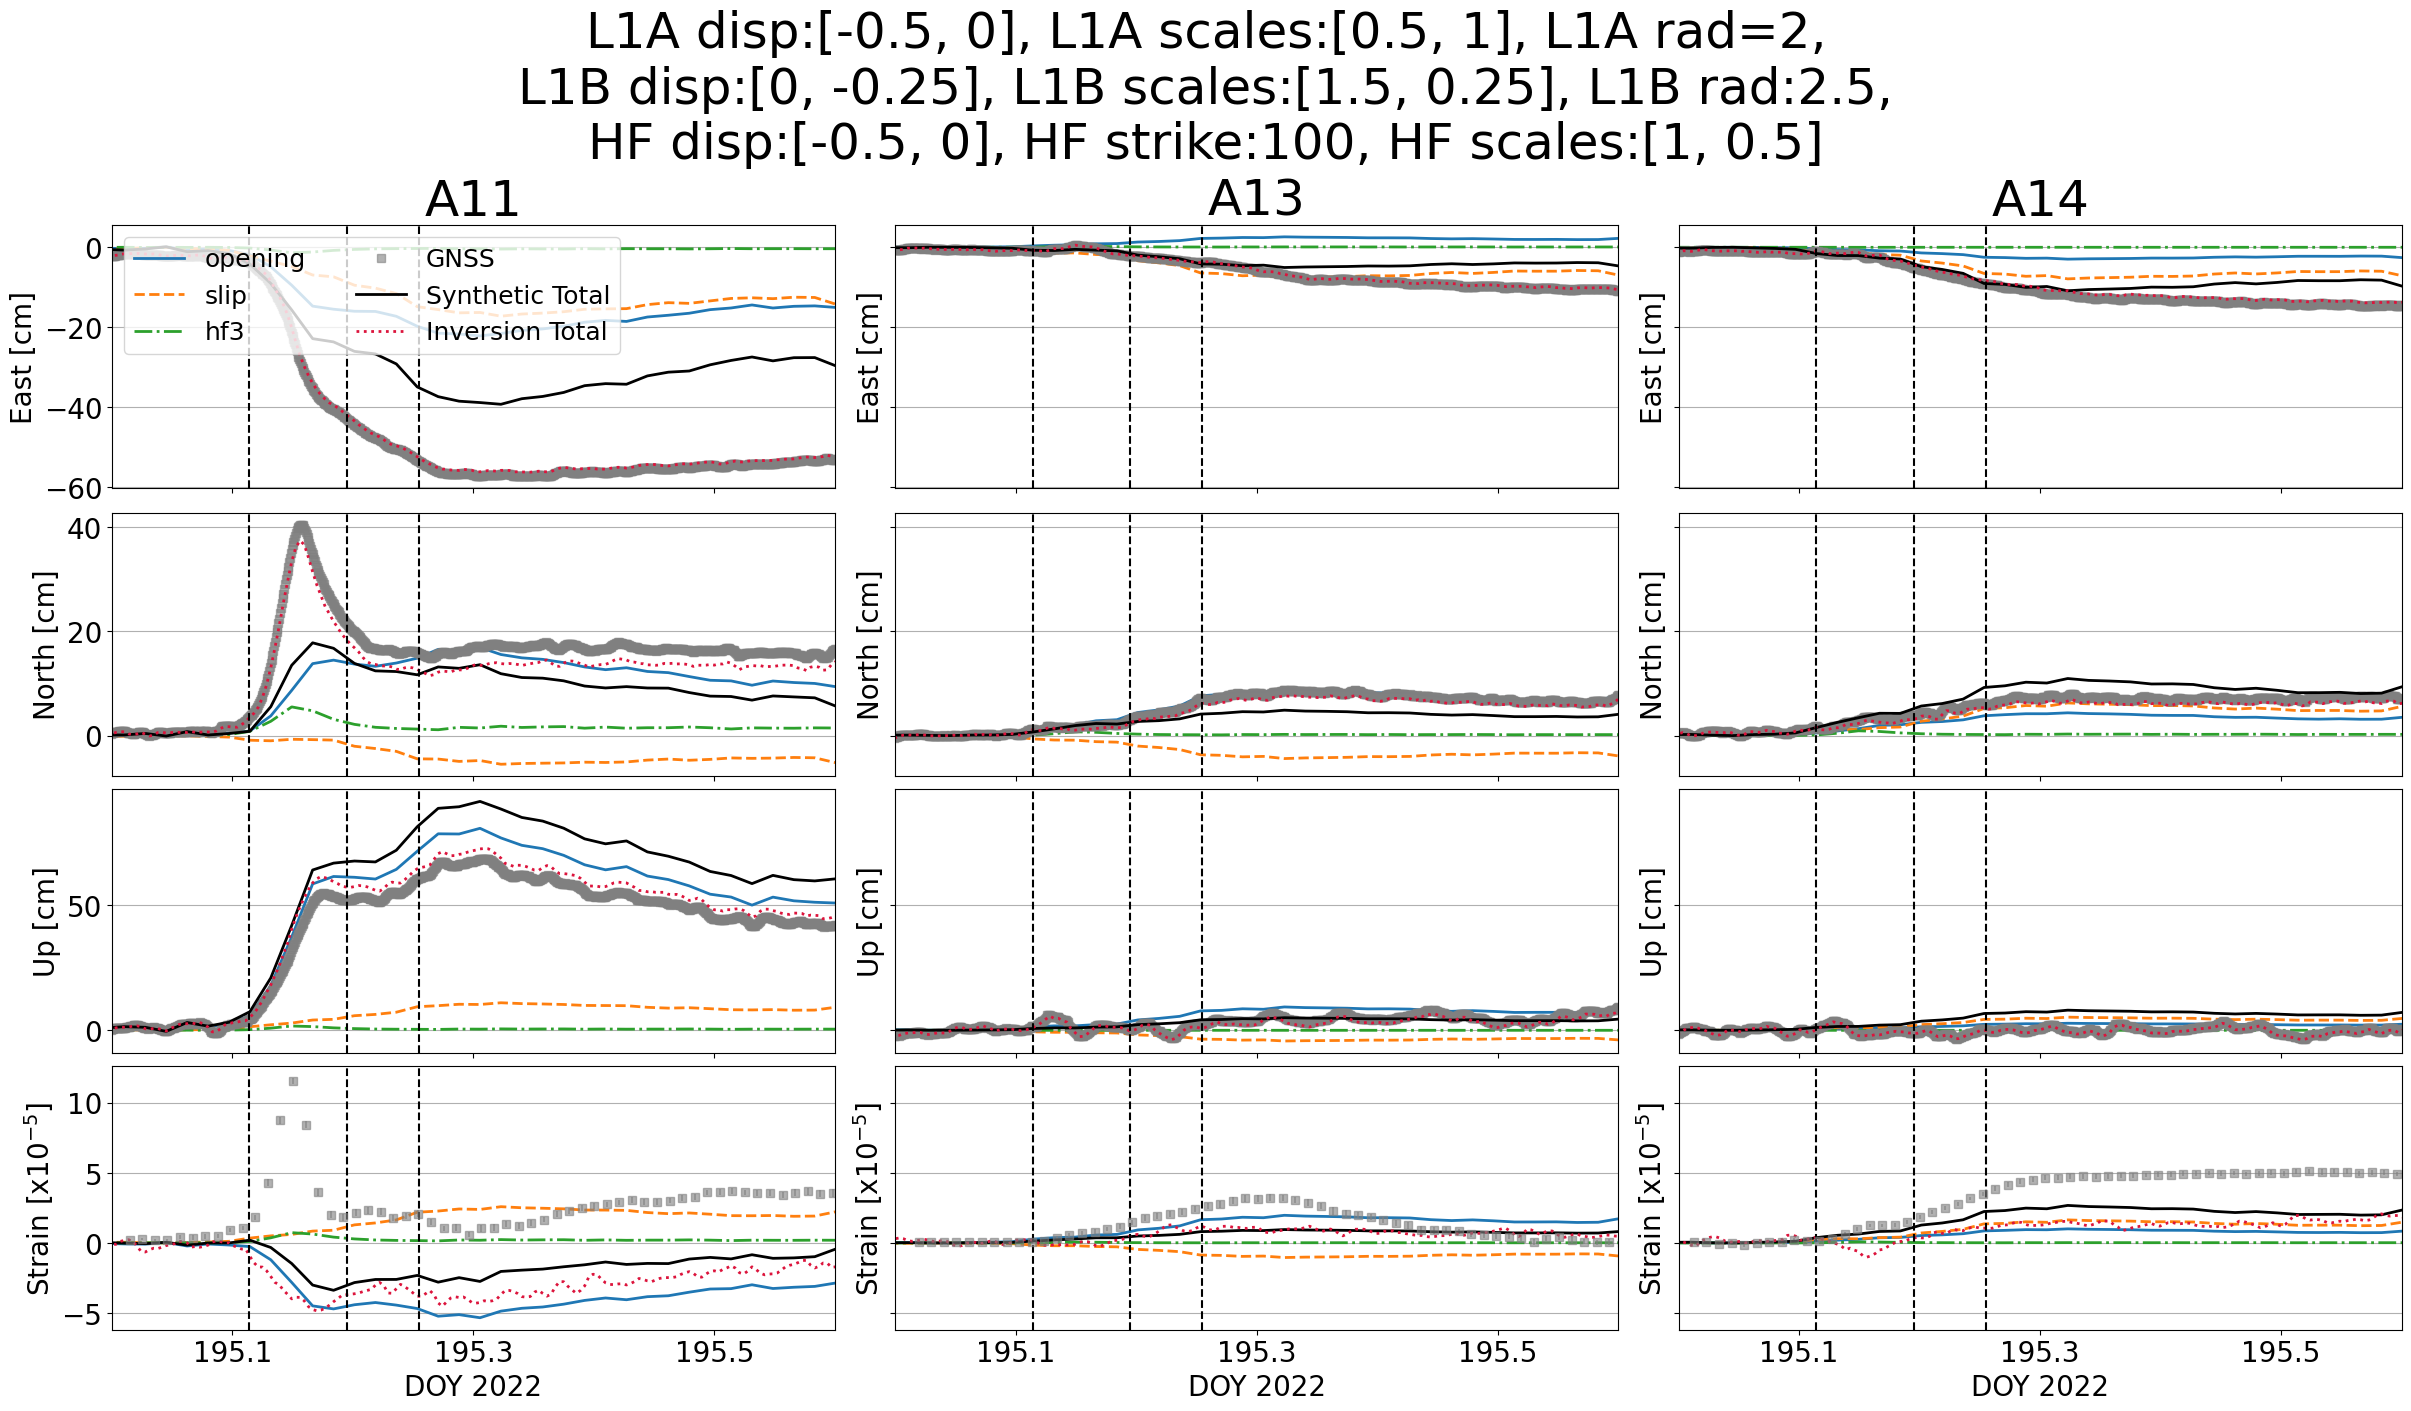

In [16]:
plot_displacement_summary(ds_station)

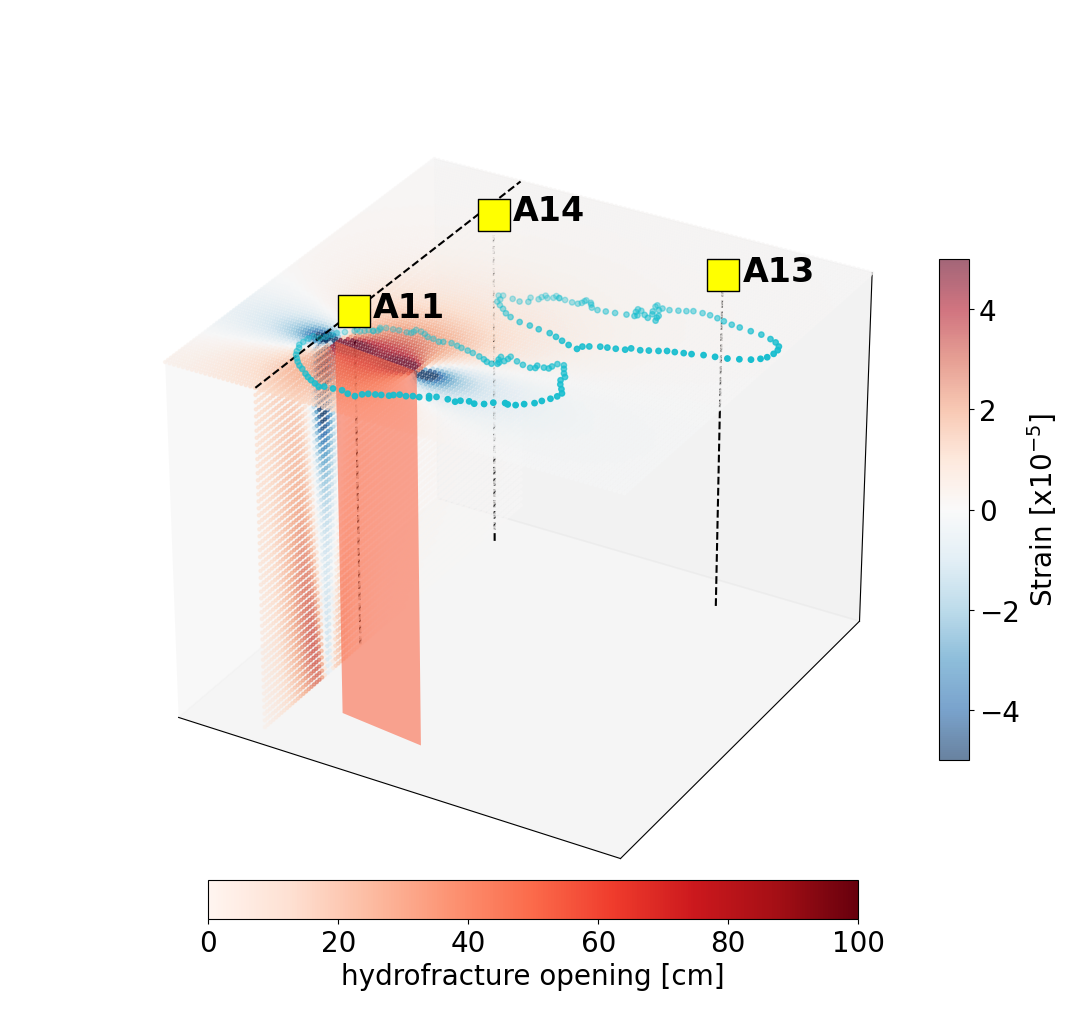

In [17]:
strain_surf = U_total_s[2,...,11]
strain_cross = U_total_c[2,...,11]
vmin = -5
vmax = 5
deformation_title = 'hydrofracture opening [cm]'

from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.colors as colors

import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig, ax3d = plt.subplots(figsize=(13,13), subplot_kw={'projection': '3d','computed_zorder':False})

# Plot the transect with a diverging red/blue colormap centered at 0

xlim = [-2,3]
ylim = [-3.5, 3.5]

sc = ax3d.scatter(X_s.flatten(), Y_s.flatten(), Z_s.flatten(), c=strain_surf.flatten(),
                  cmap='RdBu_r', s=5, alpha=0.6, zorder=1, vmin=vmin, vmax=vmax)
sc = ax3d.scatter(X_c.flatten(), Y_c.flatten(), -Z_c.flatten(), c=strain_cross.flatten(),
                  cmap='RdBu_r', s=5, alpha=0.6, zorder=0, vmin=vmin, vmax=vmax)

cb_ax = inset_axes(ax3d,
                   width="3%",  # width: % of parent_bbox width
                   height="50%",  # height: % of parent_bbox height
                   loc='center right',
                   borderpad=1.5)
cb = fig.colorbar(sc, cax=cb_ax)
cb.set_label('Strain [x10$^{-5}$]')

ax3d.scatter(x_L1A, y_L1A, np.zeros_like(x_L1A), s=15, color='tab:cyan', zorder=2)
ax3d.scatter(x_L1B, y_L1B, np.zeros_like(x_L1B), s=15, color='tab:cyan', zorder=2)

star_coords = [[x_a11, y_a11], [x_a13, y_a13], [x_a14, y_a14]]
star_labels = ['A11', 'A13', 'A14']
for (x, y), label in zip(star_coords, star_labels):
    ax3d.scatter(x, y, 0, s=500, marker='s', color='yellow', edgecolors='black', zorder=2)
    ax3d.text(x + 0.3, y -0.2, 0, label, color='black', fontsize=24, ha='left', va='bottom', fontweight='bold')
    ax3d.plot([x, x], [y, y], [-0.9, 0], color='black', linestyle='dashed', linewidth=1.5, zorder=-1)

# Add horizontal line for transect
y_vals = y_cross
x_vals = np.full_like(y_vals, x_a11)
z_vals = np.zeros_like(y_vals)
ax3d.plot(x_vals, y_vals, z_vals, color='black', linestyle='--', label='x = x_a11', zorder=1)

# Color-mapped patches
norm_bed = colors.Normalize(vmin=0, vmax=100)
sm_bed = cm.ScalarMappable(cmap='Reds', norm=norm_bed)
sm_bed.set_array([])  # Needed for colorbar
# Normalize HF_3s values for colormap
norm = colors.Normalize(vmin=0, vmax=1)
cmap = plt.get_cmap('Reds')
HF3_open = opening_synthetic_hf3[23]

center = [hf_cx, hf_cy, -hf_depth]
strike_val = hf_strike
dip_val = hf_dip
color = cmap(HF3_open) 
# Create and plot the patch in 3D
vertices = create_patch(center, strike_val, dip_val,hf_length,hf_width)
poly = Poly3DCollection([vertices], facecolor=color,alpha=0.6)
sc = ax3d.add_collection3d(poly)
    
# Add second colorbar
cbar_ax2 = fig.add_axes([0.28, 0.18, 0.5, 0.03])  # Adjust as needed
cb2 = fig.colorbar(sm_bed, cax=cbar_ax2, orientation='horizontal')
cb2.set_label(deformation_title)

# Set limits
ax3d.set_xlim([-2, 3])
ax3d.set_ylim([-3.5, 3.5])
ax3d.set_zlim([-0.95, 0])

# Remove all ticks and axis labels
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])
ax3d.set_xticklabels([])
ax3d.set_yticklabels([])
ax3d.set_zticklabels([])
ax3d.set_xlabel('')
ax3d.set_ylabel('')
ax3d.set_zlabel('')

ax3d.set_aspect(aspect='equalxy')
ax3d.set_box_aspect(aspect=(1, 1, 0.8), zoom=0.8)

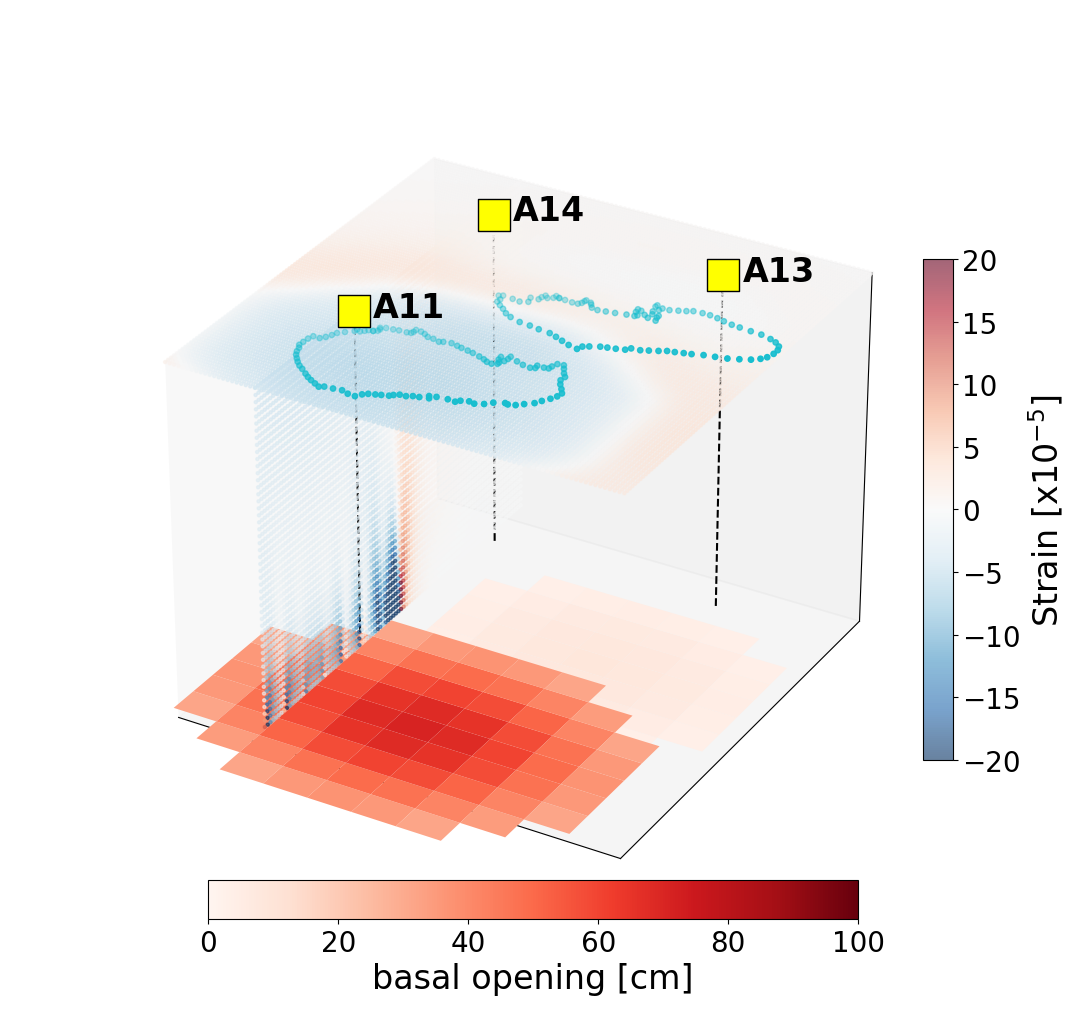

In [18]:
strain_surf = U_total_s[0,...,11]
strain_cross = U_total_c[0,...,11]
vmin = -20
vmax = 20
deformation_title = 'basal opening [cm]'

from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
plt.rcParams.update({
    'font.size': 24,          # General font size
    'axes.titlesize': 36,     # Title font size
    'axes.labelsize': 24,     # Axis label font size
    'xtick.labelsize': 20,    # X-axis tick label size
    'ytick.labelsize': 20,    # Y-axis tick label size
    'legend.fontsize': 28,    # Legend font size
    'figure.titlesize': 36,   # Suptitle font size
})
fig, ax3d = plt.subplots(figsize=(13,13), subplot_kw={'projection': '3d','computed_zorder':False})

# Plot the transect with a diverging red/blue colormap centered at 0

xlim = [-2,3]
ylim = [-3.5, 3.5]

sc = ax3d.scatter(X_s.flatten(), Y_s.flatten(), Z_s.flatten(), c=strain_surf.flatten(),
                  cmap='RdBu_r', s=5, alpha=0.6, zorder=1, vmin=vmin, vmax=vmax)
sc = ax3d.scatter(X_c.flatten(), Y_c.flatten(), -Z_c.flatten(), c=strain_cross.flatten(),
                  cmap='RdBu_r', s=5, alpha=0.6, zorder=0, vmin=vmin, vmax=vmax)

cb_ax = inset_axes(ax3d,
                   width="3%",  # width: % of parent_bbox width
                   height="50%",  # height: % of parent_bbox height
                   loc='center right',
                   borderpad=1.5)
cb = fig.colorbar(sc, cax=cb_ax)
cb.set_label('Strain [x10$^{-5}$]')

ax3d.scatter(x_L1A, y_L1A, np.zeros_like(x_L1A), s=15, color='tab:cyan', zorder=2)
ax3d.scatter(x_L1B, y_L1B, np.zeros_like(x_L1B), s=15, color='tab:cyan', zorder=2)

star_coords = [[x_a11, y_a11], [x_a13, y_a13], [x_a14, y_a14]]
star_labels = ['A11', 'A13', 'A14']
for (x, y), label in zip(star_coords, star_labels):
    ax3d.scatter(x, y, 0, s=500, marker='s', color='yellow', edgecolors='black', zorder=2)
    ax3d.text(x + 0.3, y -0.2, 0, label, color='black', fontsize=24, ha='left', va='bottom', fontweight='bold')
    ax3d.plot([x, x], [y, y], [-0.9, 0], color='black', linestyle='dashed', linewidth=1.5, zorder=-1)

# Add horizontal line for transect
x_vals = x_cross
y_vals = np.full_like(x_vals, y_a11)
z_vals = np.zeros_like(y_vals)
ax3d.plot(x_vals, y_vals, z_vals, color='black', linestyle='--', label='x = x_a11', zorder=1)

# Color-mapped patches
norm_bed = colors.Normalize(vmin=0, vmax=100)
sm_bed = cm.ScalarMappable(cmap='Reds', norm=norm_bed)
sm_bed.set_array([])  # Needed for colorbar
cmap = plt.get_cmap('Reds')
for xp_l,yp_l,opening_synthetic in zip([xp_la,xp_lb],[yp_la,yp_lb],[opening_synthetic_a,opening_synthetic_b]):
    for i in range(0, xp_l.shape[0]):
        center = [xp_l[i], yp_l[i], -0.93278072]
        strike_val = 180
        dip_val = 0
        color = cmap(norm_bed(opening_synthetic[23, i]))
        vertices = create_patch(center, strike_val, dip_val, 0.5, 0.5)
        poly = Poly3DCollection([vertices], facecolor=color, zorder=-1)
        sc = ax3d.add_collection3d(poly)
    

# Add second colorbar
cbar_ax2 = fig.add_axes([0.28, 0.18, 0.5, 0.03])  # Adjust as needed
cb2 = fig.colorbar(sm_bed, cax=cbar_ax2, orientation='horizontal')
cb2.set_label(deformation_title)

# Set limits
ax3d.set_xlim([-2, 3])
ax3d.set_ylim([-3.5, 3.5])
ax3d.set_zlim([-0.95, 0])

# Remove all ticks and axis labels
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])
ax3d.set_xticklabels([])
ax3d.set_yticklabels([])
ax3d.set_zticklabels([])
ax3d.set_xlabel('')
ax3d.set_ylabel('')
ax3d.set_zlabel('')

ax3d.set_aspect(aspect='equalxy')
ax3d.set_box_aspect(aspect=(1, 1, 0.8), zoom=0.8)

# Perturbation

In [37]:
# Perturb original
L1A_disp = [-0.5, 0]
L1A_scale = [1, 1.5]
L1A_rad = 2

L1B_disp = [0, -1]
L1B_scale = [1.5, 0.25]
L1B_rad = 2.5

HF_disp = [-0.5, 0.1]
HF3_strike = 100
HF3_scales = [1.5,2] # lengthscale, opening_scale


In [38]:
# now we try synthetic
# now let's create our synthetic problem
# first, generate patch
#cx_true = 0.2 # for comparison with original
#cy_true = -1.5
#cx_true = 0.2
#cy_true = -2.5
xp_lb, yp_lb, synthetic_blister = generate_blister(L1B_rad, 0.5)
xp_lb += Cx_L1B + L1B_disp[0]
yp_lb += Cy_L1B + L1B_disp[1]


opening_scales_b = np.interp(timesteps,sq11['time'],sq11['up'])/np.max(sq11['up'])
test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_b*L1B_scale[0])
opening_synthetic_b = test_grid*scale_grid
test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_b*L1B_scale[1])
sliding_synthetic_b = test_grid*scale_grid

xp_la, yp_la, synthetic_blister = generate_blister(L1A_rad, 0.5)
xp_la += Cx_L1A + L1A_disp[0]
yp_la += Cy_L1A + L1A_disp[1]


opening_scales_a =np.interp(timesteps,a14_ld.doy_decimal,a14_ld.strain)/np.nanmax(a14_ld.strain)
test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_a*L1A_scale[0])
opening_synthetic_a = test_grid*scale_grid
test_grid,scale_grid = np.meshgrid(synthetic_blister,opening_scales_a*L1A_scale[1])
sliding_synthetic_a = test_grid*scale_grid


In [39]:
# hydrofracture, just single patch
hf_depth = 0.5
hf_length = HF3_scales[0]
hf_width = 1
hf_strike = HF3_strike
hf_dip = 90
hf_cx,hf_cy = Cx_L1B+HF_disp[0],Cy_L1B+HF_disp[1]
scales = np.interp(timesteps,a11_ld.doy_decimal,a11_ld.strain)/np.nanmax(a11_ld.strain)
opening_synthetic_hf3 = HF3_scales[1]*scales

In [40]:
x_apres = np.array([x_a11,x_a13,x_a14])
y_apres = np.array([y_a11,y_a13,y_a14])
z = np.array([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
X,Y,Z = np.meshgrid(x_apres,y_apres,z) # apres sites are along diagonal
n = (X.shape[0],X.shape[1],X.shape[2],12) 

In [41]:
# displacements for synthetic opening and hydrofracture
hf3_timeseries_synthetic = []
opening_timeseries_synthetic = []
slips_timeseries_synthetic = []

n_source = 3 # open, slip, hf3
x_surf = np.linspace(-2, 3,100)
y_surf = np.linspace(-3.5, 3.5,100)
z_surf = np.array([0])
X_s,Y_s,Z_s = np.meshgrid(x_surf,y_surf,z_surf)
# for slip and opening
#x_cross = np.linspace(-2, 3,100)
#y_cross = np.array([y_a11])
#z_cross = np.linspace(0,0.6,50)
# for hf
y_cross = np.linspace(-3.5, 3.5,100)
x_cross = np.array([x_a11])
z_cross = np.linspace(0,0.9,50)
X_c,Y_c,Z_c = np.meshgrid(x_cross,y_cross,z_cross)
n_s = (n_source,X_s.shape[0],X_s.shape[1],X_s.shape[2],12)
U_total_s = np.zeros(n_s)
n_c = (n_source,X_c.shape[0],X_c.shape[1],X_c.shape[2],12)
U_total_c = np.zeros(n_c)

for t in range(len(timesteps)):
    print(f'Timestep {t} out of {len(timesteps)}')
    U_HF3 = np.zeros(n)
    total = HF3['n']
    count = 0
    W = HF3['width']
    L = HF3['length']
    HF3_open = opening_synthetic_hf3[t]
    x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
    U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
    U_HF3 = U_HF3 + convert_to_north_east(U,strike_angle)
    if t == 23:
        x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
        U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
        U_total_s[2,...] = U_total_s[2,...] + convert_to_north_east(U,strike_angle)

        x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, hf_cx,hf_cy, hf_depth, hf_strike,hf_dip,0,hf_length,hf_width,0,HF3_open*100)
        U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
        U_total_c[2,...] = U_total_c[2,...] + convert_to_north_east(U,strike_angle)
    hf3_timeseries_synthetic.append(U_HF3)
    
    U_opening_flat = np.zeros(n)
    U_slip_flat = np.zeros(n)
    for xp_l,yp_l,opening_synthetic,sliding_synthetic in zip([xp_la,xp_lb],[yp_la,yp_lb],[opening_synthetic_a,opening_synthetic_b],[sliding_synthetic_a,sliding_synthetic_b]):
        for i in range(0,xp_l.shape[0]):
            #if count%10 == 0:
                #print(f'{count}/{total}')
            count += 1
            # opening
            x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
            U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
            U_opening_flat = U_opening_flat + convert_to_north_east(U_1,strike_angle)
    
            # slip 
            x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X,Y, Z, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
            U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
            U_slip_flat = U_slip_flat + convert_to_north_east(U,strike_angle)
    
            if t == 23:
                # opening
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
                U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_total_s[0,...] = U_total_s[0,...] + convert_to_north_east(U_1,strike_angle)
    
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,0,opening_synthetic[t][i])
                U_1 = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_total_c[0,...] = U_total_c[0,...] + convert_to_north_east(U_1,strike_angle)

                # slip
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_s,Y_s, Z_s, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
                U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_total_s[1,...] = U_total_s[1,...] + convert_to_north_east(U,strike_angle)
    
                x_rot,y_rot,z_rot,depth,al1,al2,aw1,aw2, disl1, disl2, disl3,strike_angle, dip_angle = convert_to_okada_input(X_c,Y_c, Z_c, xp_l[i],yp_l[i], 0.93278072, 180,0,-90,0.5,0.5,sliding_synthetic[t][i],0)
                U = DC3D(alpha,x_rot,y_rot,-z_rot,depth,dip_angle,al1,al2,aw1,aw2, disl1, disl2, disl3)
                U_total_c[1,...] = U_total_c[1,...] + convert_to_north_east(U,strike_angle)

            
    opening_timeseries_synthetic.append(U_opening_flat)
    slips_timeseries_synthetic.append(U_slip_flat)


Timestep 0 out of 58
Timestep 1 out of 58
Timestep 2 out of 58
Timestep 3 out of 58
Timestep 4 out of 58
Timestep 5 out of 58
Timestep 6 out of 58
Timestep 7 out of 58
Timestep 8 out of 58
Timestep 9 out of 58
Timestep 10 out of 58
Timestep 11 out of 58
Timestep 12 out of 58
Timestep 13 out of 58
Timestep 14 out of 58
Timestep 15 out of 58
Timestep 16 out of 58
Timestep 17 out of 58
Timestep 18 out of 58
Timestep 19 out of 58
Timestep 20 out of 58
Timestep 21 out of 58
Timestep 22 out of 58
Timestep 23 out of 58
Timestep 24 out of 58
Timestep 25 out of 58
Timestep 26 out of 58
Timestep 27 out of 58
Timestep 28 out of 58
Timestep 29 out of 58
Timestep 30 out of 58
Timestep 31 out of 58
Timestep 32 out of 58
Timestep 33 out of 58
Timestep 34 out of 58
Timestep 35 out of 58
Timestep 36 out of 58
Timestep 37 out of 58
Timestep 38 out of 58
Timestep 39 out of 58
Timestep 40 out of 58
Timestep 41 out of 58
Timestep 42 out of 58
Timestep 43 out of 58
Timestep 44 out of 58
Timestep 45 out of 5

In [42]:
# Input dictionary
apres_dict = {
    'opening_synthetic': opening_timeseries_synthetic,
    'slip_synthetic': slips_timeseries_synthetic,
    'hf3_synthetic': hf3_timeseries_synthetic,
    'time': timesteps,
    'x': x_apres,
    'y': y_apres,
    'z': z
}

# Station index map: maps station name to (x_index, y_index)
station_map = {
    "a11": (0, 0),
    "a13": (1, 1),
    "a14": (2, 2),
}

dislocations = ["ue", "un", "uz", "uee", "une", "uze", "uen", "unn", "uzn", "uez", "unz", "uzz"]

# Extract coordinate arrays
time = apres_dict.pop("time")
z = apres_dict.pop("z")
x = apres_dict.pop("x")
y = apres_dict.pop("y")

# Build the full dataset first (as in your original code)
data_vars_full = {
    key: (("time", "x", "y", "z", "disl"), np.stack([np.squeeze(d) for d in value], axis=0))
    for key, value in apres_dict.items()
}

ds_apres = xr.Dataset(
    data_vars=data_vars_full,
    coords={
        "time": time,
        "x": x,
        "y": y,
        "z": z,
        "disl": dislocations,
    },
)

# Build per-station dataset from ds_apres
station_names = []
x_vals = []
y_vals = []
station_data_vars = {}

for var in ds_apres.data_vars:
    var_data = []
    for station, (ix, iy) in station_map.items():
        slice_ = ds_apres[var].isel(x=ix, y=iy)  # shape: (time, z, disl)
        var_data.append(slice_.expand_dims(station=[station]))
        
        if var == list(ds_apres.data_vars)[0]:  # only collect coords once
            station_names.append(station)
            x_vals.append(ds_apres.x[ix].item())
            y_vals.append(ds_apres.y[iy].item())
    
    station_data_vars[var] = xr.concat(var_data, dim="station")

# Final per-station dataset
ds_station = xr.Dataset(
    data_vars=station_data_vars,
    coords={
        "time": time,
        "z": z,
        "disl": dislocations,
        "station": station_names,
        "x": ("station", x_vals),
        "y": ("station", y_vals),
    },
)

Running L1A disp:[-0.5, 0], L1A scales:[1, 1.5], L1A rad=2,
L1B disp:[0, -1], L1B scales:[1.5, 0.25], L1B rad:2.5,
HF disp:[-0.5, 0.1], HF strike:100, HF scales:[1.5, 2]
...


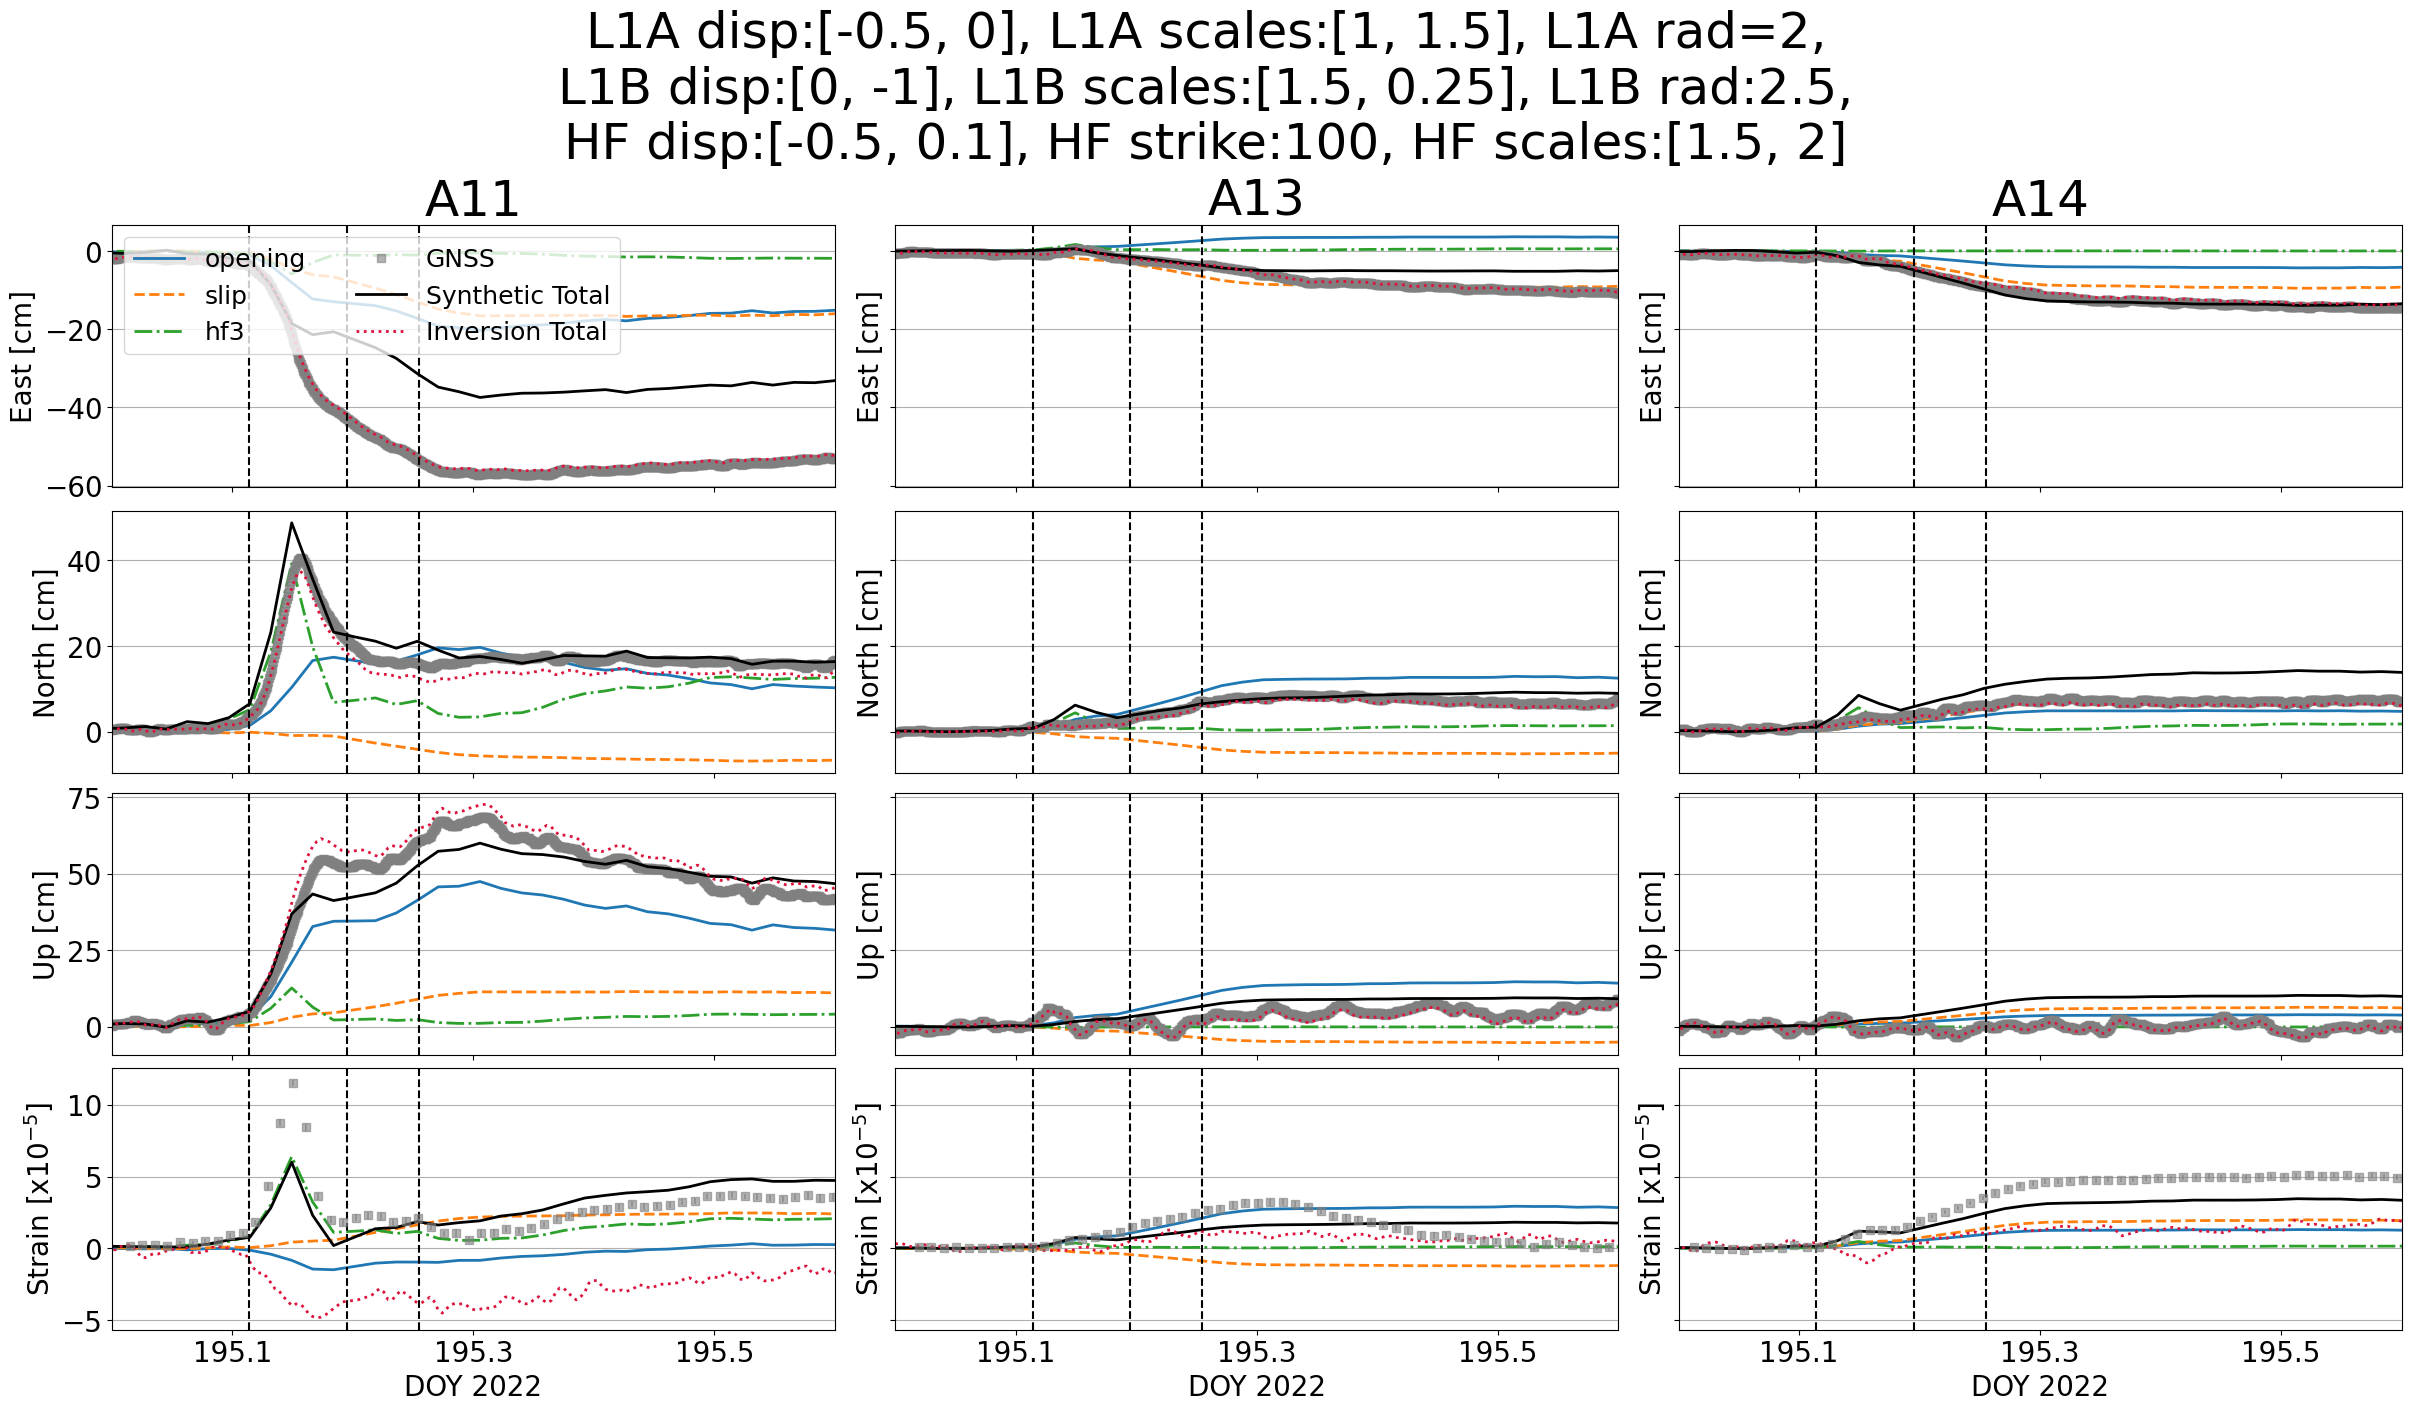

In [43]:
plot_displacement_summary(ds_station)

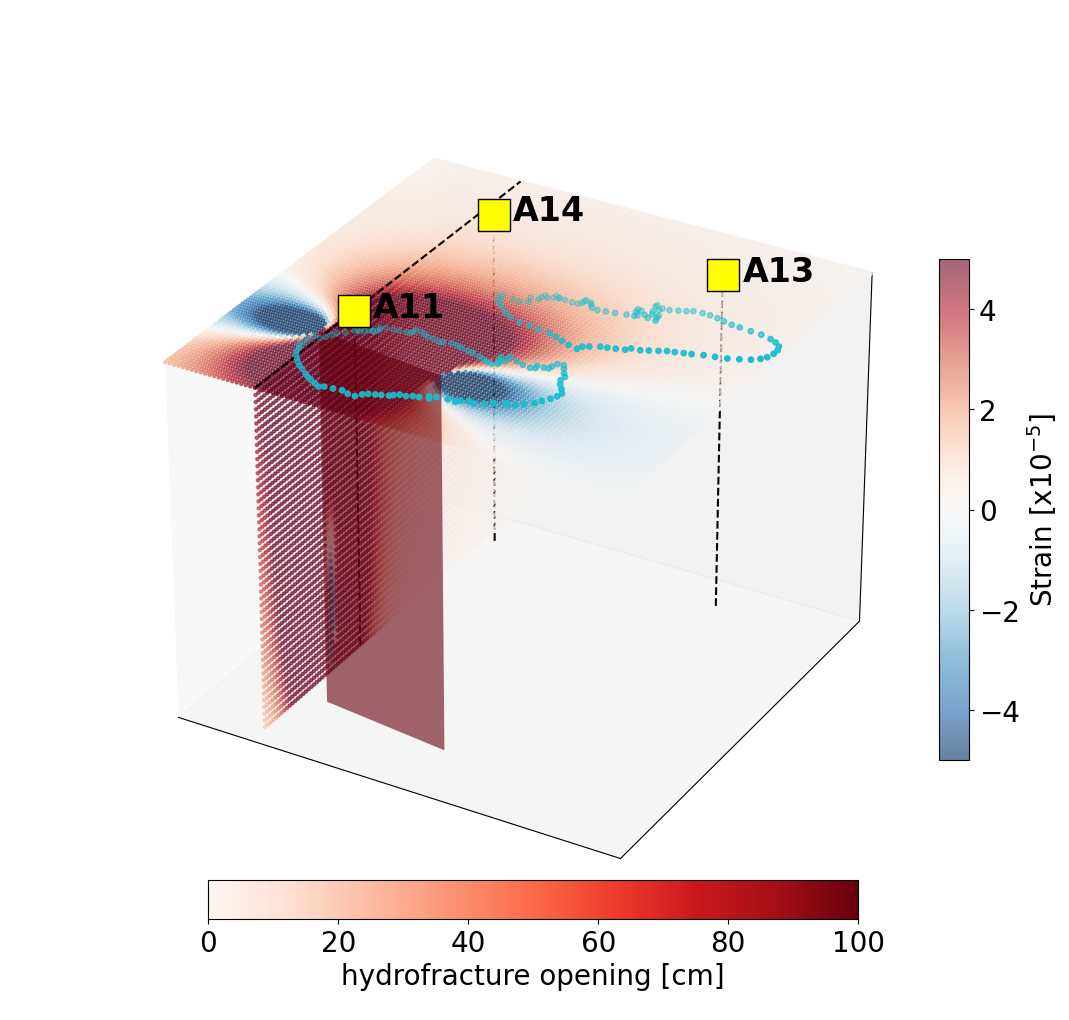

In [44]:
strain_surf = U_total_s[2,...,11]
strain_cross = U_total_c[2,...,11]
vmin = -5
vmax = 5
deformation_title = 'hydrofracture opening [cm]'

from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.colors as colors

import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig, ax3d = plt.subplots(figsize=(13,13), subplot_kw={'projection': '3d','computed_zorder':False})

# Plot the transect with a diverging red/blue colormap centered at 0

xlim = [-2,3]
ylim = [-3.5, 3.5]

sc = ax3d.scatter(X_s.flatten(), Y_s.flatten(), Z_s.flatten(), c=strain_surf.flatten(),
                  cmap='RdBu_r', s=5, alpha=0.6, zorder=1, vmin=vmin, vmax=vmax)
sc = ax3d.scatter(X_c.flatten(), Y_c.flatten(), -Z_c.flatten(), c=strain_cross.flatten(),
                  cmap='RdBu_r', s=5, alpha=0.6, zorder=0, vmin=vmin, vmax=vmax)

cb_ax = inset_axes(ax3d,
                   width="3%",  # width: % of parent_bbox width
                   height="50%",  # height: % of parent_bbox height
                   loc='center right',
                   borderpad=1.5)
cb = fig.colorbar(sc, cax=cb_ax)
cb.set_label('Strain [x10$^{-5}$]')

ax3d.scatter(x_L1A, y_L1A, np.zeros_like(x_L1A), s=15, color='tab:cyan', zorder=2)
ax3d.scatter(x_L1B, y_L1B, np.zeros_like(x_L1B), s=15, color='tab:cyan', zorder=2)

star_coords = [[x_a11, y_a11], [x_a13, y_a13], [x_a14, y_a14]]
star_labels = ['A11', 'A13', 'A14']
for (x, y), label in zip(star_coords, star_labels):
    ax3d.scatter(x, y, 0, s=500, marker='s', color='yellow', edgecolors='black', zorder=2)
    ax3d.text(x + 0.3, y -0.2, 0, label, color='black', fontsize=24, ha='left', va='bottom', fontweight='bold')
    ax3d.plot([x, x], [y, y], [-0.9, 0], color='black', linestyle='dashed', linewidth=1.5, zorder=-1)

# Add horizontal line for transect
y_vals = y_cross
x_vals = np.full_like(y_vals, x_a11)
z_vals = np.zeros_like(y_vals)
ax3d.plot(x_vals, y_vals, z_vals, color='black', linestyle='--', label='x = x_a11', zorder=1)

# Color-mapped patches
norm_bed = colors.Normalize(vmin=0, vmax=100)
sm_bed = cm.ScalarMappable(cmap='Reds', norm=norm_bed)
sm_bed.set_array([])  # Needed for colorbar
# Normalize HF_3s values for colormap
norm = colors.Normalize(vmin=0, vmax=1)
cmap = plt.get_cmap('Reds')
HF3_open = opening_synthetic_hf3[23]

center = [hf_cx, hf_cy, -hf_depth]
strike_val = hf_strike
dip_val = hf_dip
color = cmap(HF3_open) 
# Create and plot the patch in 3D
vertices = create_patch(center, strike_val, dip_val,hf_length,hf_width)
poly = Poly3DCollection([vertices], facecolor=color,alpha=0.6)
sc = ax3d.add_collection3d(poly)
    
# Add second colorbar
cbar_ax2 = fig.add_axes([0.28, 0.18, 0.5, 0.03])  # Adjust as needed
cb2 = fig.colorbar(sm_bed, cax=cbar_ax2, orientation='horizontal')
cb2.set_label(deformation_title)

# Set limits
ax3d.set_xlim([-2, 3])
ax3d.set_ylim([-3.5, 3.5])
ax3d.set_zlim([-0.95, 0])

# Remove all ticks and axis labels
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])
ax3d.set_xticklabels([])
ax3d.set_yticklabels([])
ax3d.set_zticklabels([])
ax3d.set_xlabel('')
ax3d.set_ylabel('')
ax3d.set_zlabel('')

ax3d.set_aspect(aspect='equalxy')
ax3d.set_box_aspect(aspect=(1, 1, 0.8), zoom=0.8)

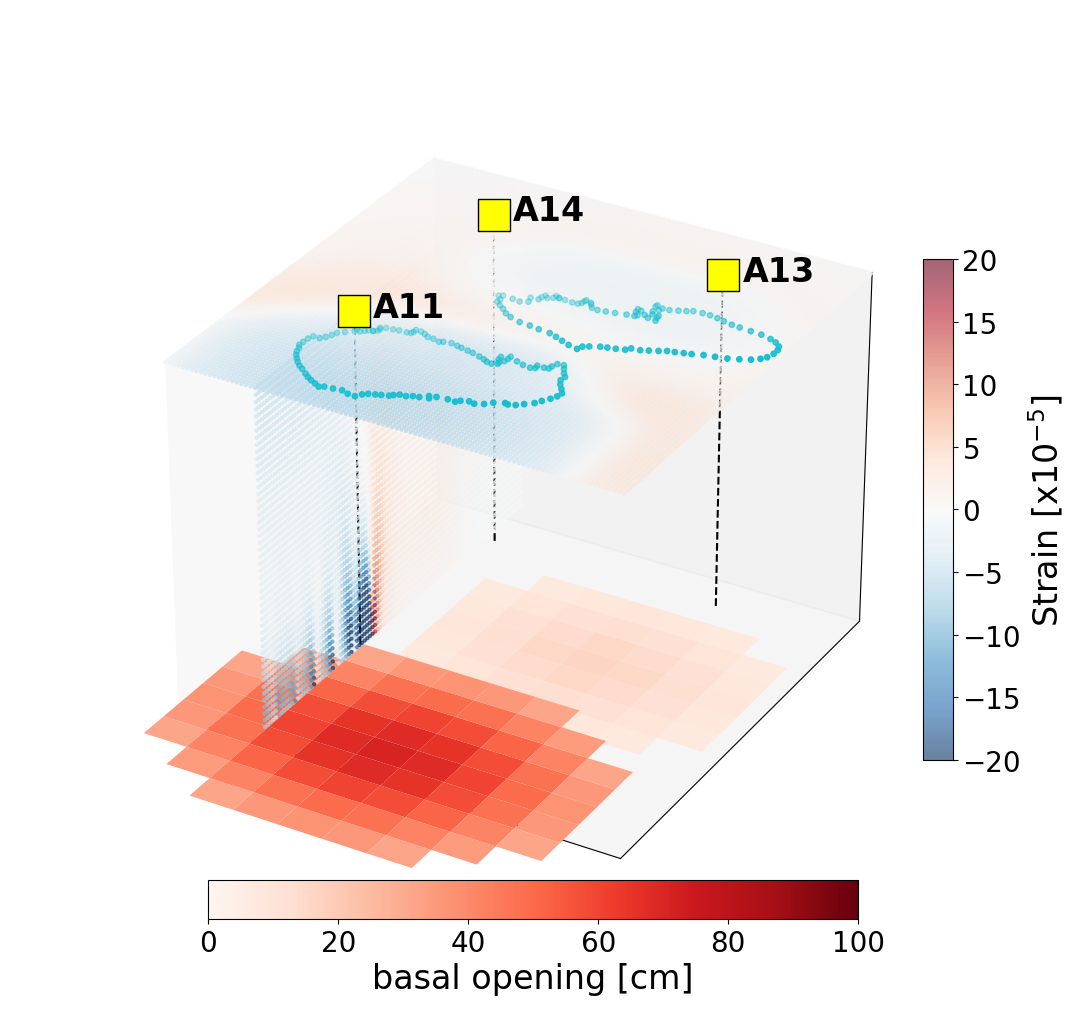

In [45]:
strain_surf = U_total_s[0,...,11]
strain_cross = U_total_c[0,...,11]
vmin = -20
vmax = 20
deformation_title = 'basal opening [cm]'

from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
plt.rcParams.update({
    'font.size': 24,          # General font size
    'axes.titlesize': 36,     # Title font size
    'axes.labelsize': 24,     # Axis label font size
    'xtick.labelsize': 20,    # X-axis tick label size
    'ytick.labelsize': 20,    # Y-axis tick label size
    'legend.fontsize': 28,    # Legend font size
    'figure.titlesize': 36,   # Suptitle font size
})
fig, ax3d = plt.subplots(figsize=(13,13), subplot_kw={'projection': '3d','computed_zorder':False})

# Plot the transect with a diverging red/blue colormap centered at 0

xlim = [-2,3]
ylim = [-3.5, 3.5]

sc = ax3d.scatter(X_s.flatten(), Y_s.flatten(), Z_s.flatten(), c=strain_surf.flatten(),
                  cmap='RdBu_r', s=5, alpha=0.6, zorder=1, vmin=vmin, vmax=vmax)
sc = ax3d.scatter(X_c.flatten(), Y_c.flatten(), -Z_c.flatten(), c=strain_cross.flatten(),
                  cmap='RdBu_r', s=5, alpha=0.6, zorder=0, vmin=vmin, vmax=vmax)

cb_ax = inset_axes(ax3d,
                   width="3%",  # width: % of parent_bbox width
                   height="50%",  # height: % of parent_bbox height
                   loc='center right',
                   borderpad=1.5)
cb = fig.colorbar(sc, cax=cb_ax)
cb.set_label('Strain [x10$^{-5}$]')

ax3d.scatter(x_L1A, y_L1A, np.zeros_like(x_L1A), s=15, color='tab:cyan', zorder=2)
ax3d.scatter(x_L1B, y_L1B, np.zeros_like(x_L1B), s=15, color='tab:cyan', zorder=2)

star_coords = [[x_a11, y_a11], [x_a13, y_a13], [x_a14, y_a14]]
star_labels = ['A11', 'A13', 'A14']
for (x, y), label in zip(star_coords, star_labels):
    ax3d.scatter(x, y, 0, s=500, marker='s', color='yellow', edgecolors='black', zorder=2)
    ax3d.text(x + 0.3, y -0.2, 0, label, color='black', fontsize=24, ha='left', va='bottom', fontweight='bold')
    ax3d.plot([x, x], [y, y], [-0.9, 0], color='black', linestyle='dashed', linewidth=1.5, zorder=-1)

# Add horizontal line for transect
x_vals = x_cross
y_vals = np.full_like(x_vals, y_a11)
z_vals = np.zeros_like(y_vals)
ax3d.plot(x_vals, y_vals, z_vals, color='black', linestyle='--', label='x = x_a11', zorder=1)

# Color-mapped patches
norm_bed = colors.Normalize(vmin=0, vmax=100)
sm_bed = cm.ScalarMappable(cmap='Reds', norm=norm_bed)
sm_bed.set_array([])  # Needed for colorbar
cmap = plt.get_cmap('Reds')
for xp_l,yp_l,opening_synthetic in zip([xp_la,xp_lb],[yp_la,yp_lb],[opening_synthetic_a,opening_synthetic_b]):
    for i in range(0, xp_l.shape[0]):
        center = [xp_l[i], yp_l[i], -0.93278072]
        strike_val = 180
        dip_val = 0
        color = cmap(norm_bed(opening_synthetic[23, i]))
        vertices = create_patch(center, strike_val, dip_val, 0.5, 0.5)
        poly = Poly3DCollection([vertices], facecolor=color, zorder=-1)
        sc = ax3d.add_collection3d(poly)
    

# Add second colorbar
cbar_ax2 = fig.add_axes([0.28, 0.18, 0.5, 0.03])  # Adjust as needed
cb2 = fig.colorbar(sm_bed, cax=cbar_ax2, orientation='horizontal')
cb2.set_label(deformation_title)

# Set limits
ax3d.set_xlim([-2, 3])
ax3d.set_ylim([-3.5, 3.5])
ax3d.set_zlim([-0.95, 0])

# Remove all ticks and axis labels
ax3d.set_xticks([])
ax3d.set_yticks([])
ax3d.set_zticks([])
ax3d.set_xticklabels([])
ax3d.set_yticklabels([])
ax3d.set_zticklabels([])
ax3d.set_xlabel('')
ax3d.set_ylabel('')
ax3d.set_zlabel('')

ax3d.set_aspect(aspect='equalxy')
ax3d.set_box_aspect(aspect=(1, 1, 0.8), zoom=0.8)